In [7]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/marketing_campaign CLEANED - COMPLETED NEW FNAL - SQL UPDATED.csv'

df = pd.read_csv(file_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
print(df.columns.tolist())

['ID', 'Year_Birth', 'Age', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Calculated_Age', 'Age_group']


In [5]:
# --- DESCRIPTIVE STATISTICS ---

print("==========================================")
print("COMPUTING SUMMARY STATISTICS")
print("==========================================")

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

summary_stats = df[numerical_cols].agg(['mean', 'median', 'min', 'max', 'std'])

formatter_dict = {col: "{:.0f}" for col in summary_stats.columns}
if 'Income' in formatter_dict:
    formatter_dict['Income'] = "${:,.0f}"

display(summary_stats.style.format(formatter=formatter_dict))


COMPUTING SUMMARY STATISTICS


,ID,Year_Birth,Age,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Calculated_Age
mean,2526,1969,57,0,1,50,314,26,169,40,27,46,2,4,3,6,5,0,0,0,0,0,0,0,57
median,2554,1970,56,0,0,51,182,10,69,13,10,27,2,4,2,5,6,0,0,0,0,0,0,0,56
min,0,1899,30,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,30
max,4998,1996,127,2,2,99,1493,199,1725,258,262,262,15,27,28,13,20,1,1,1,1,1,1,1,127
std,1447,12,12,1,1,29,342,39,228,57,41,52,2,3,3,3,2,0,0,0,0,0,0,0,12


🔍 SYSTEM DEEP-DIVE: CUSTOMER PROFILING

--- 1. AGE VS. INCOME CORRELATION ---
Mathematical Correlation Score between Age and Income: 0.16


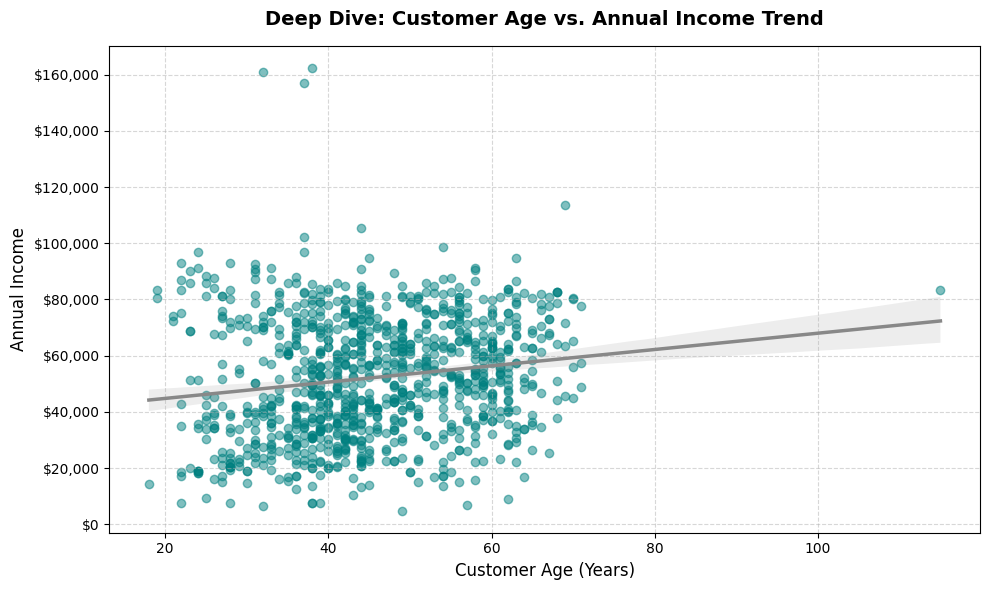

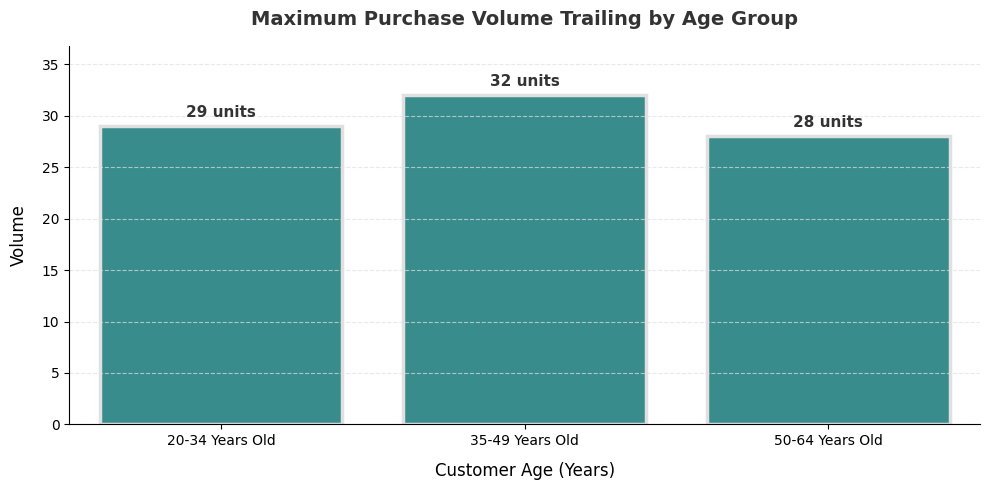

In [12]:
# ==========================================
# ADVANCED RETAIL DEEP-DIVE
# ==========================================
print("==========================================")
print("🔍 SYSTEM DEEP-DIVE: CUSTOMER PROFILING")
print("==========================================")

# 1. Calculate Age if it doesn't exist yet
df['Age'] = 2014 - df['Year_Birth']

# 2. Total Purchases Calculation
purchase_columns = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchase_columns].sum(axis=1)

# FIXED: Clean the Income column so it's a number, not text strings
if df['Income'].dtype == 'object':
    df['Income'] = df['Income'].astype(str).str.replace('$', '', regex=False)
    df['Income'] = df['Income'].str.replace(',', '', regex=False).str.strip()
    df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

# ------------------------------------------
# PART 1: AGE VS. INCOME RELATIONSHIP
# ------------------------------------------
print("\n--- 1. AGE VS. INCOME CORRELATION ---")

# Calculate the exact mathematical correlation score
age_income_corr = df['Age'].corr(df['Income'])
print(f"Mathematical Correlation Score between Age and Income: {age_income_corr:.2f}")

# Generate a detailed scatter plot with a trend line
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Age', y='Income',
            scatter_kws={'alpha':0.5, 'color':'teal'},
            line_kws={'color':'#888888', 'linewidth': 2.5})

plt.title('Deep Dive: Customer Age vs. Annual Income Trend', fontsize=14, pad=15, weight='bold')
plt.xlabel('Customer Age (Years)', fontsize=12)
plt.ylabel('Annual Income', fontsize=12)

# Added fallback checking logic so integer parsing never fails on missing values
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}" if pd.notnull(x) and not np.isnan(x) else ""))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# ==========================================
# STAKEHOLDER DEEP-DIVE: DATA PROCESSING
# ==========================================
# 1. Create the filtered dataset strictly for ages 20 to 65
df_filtered = df[(df['Age'] >= 20) & (df['Age'] < 65)].copy()

# 2. Slice into your 15-year brackets
bins = [20, 35, 50, 65]
labels = ['20-34 Years Old', '35-49 Years Old', '50-64 Years Old']
df_filtered['Age_Group'] = pd.cut(df_filtered['Age'], bins=bins, labels=labels, right=False)

# 3. Group and calculate the maximums
max_purchases = df_filtered.groupby('Age_Group', observed=False)['Total_Purchases'].max().reset_index()
max_purchases.columns = ['Age Group', 'Volume']


# ==========================================
# 2. GENERATE MATCHING VISUAL CHART ONLY
# ==========================================
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=max_purchases,
    x='Age Group',
    y='Volume',
    color='#2b9a9a',
    edgecolor='#e0e0e0',
    linewidth=2.5
)

# Wrapped label loop in a conditional safety check to prevent parsing empty heights
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and not np.isnan(height):
        ax.annotate(f"{int(height)} units",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 10),
                    textcoords='offset points',
                    fontsize=11,
                    weight='bold',
                    color='#333333')

plt.title('Maximum Purchase Volume Trailing by Age Group', fontsize=14, pad=15, color='#333333', weight='bold')
plt.xlabel('Customer Age (Years)', fontsize=12, labelpad=10)
plt.ylabel('Volume', fontsize=12, labelpad=10)

plt.ylim(0, max_purchases['Volume'].max() * 1.15)

plt.grid(True, axis='y', linestyle='--', color='#e0e0e0', alpha=0.7)
plt.grid(False, axis='x')

sns.despine()

plt.tight_layout()
plt.show()

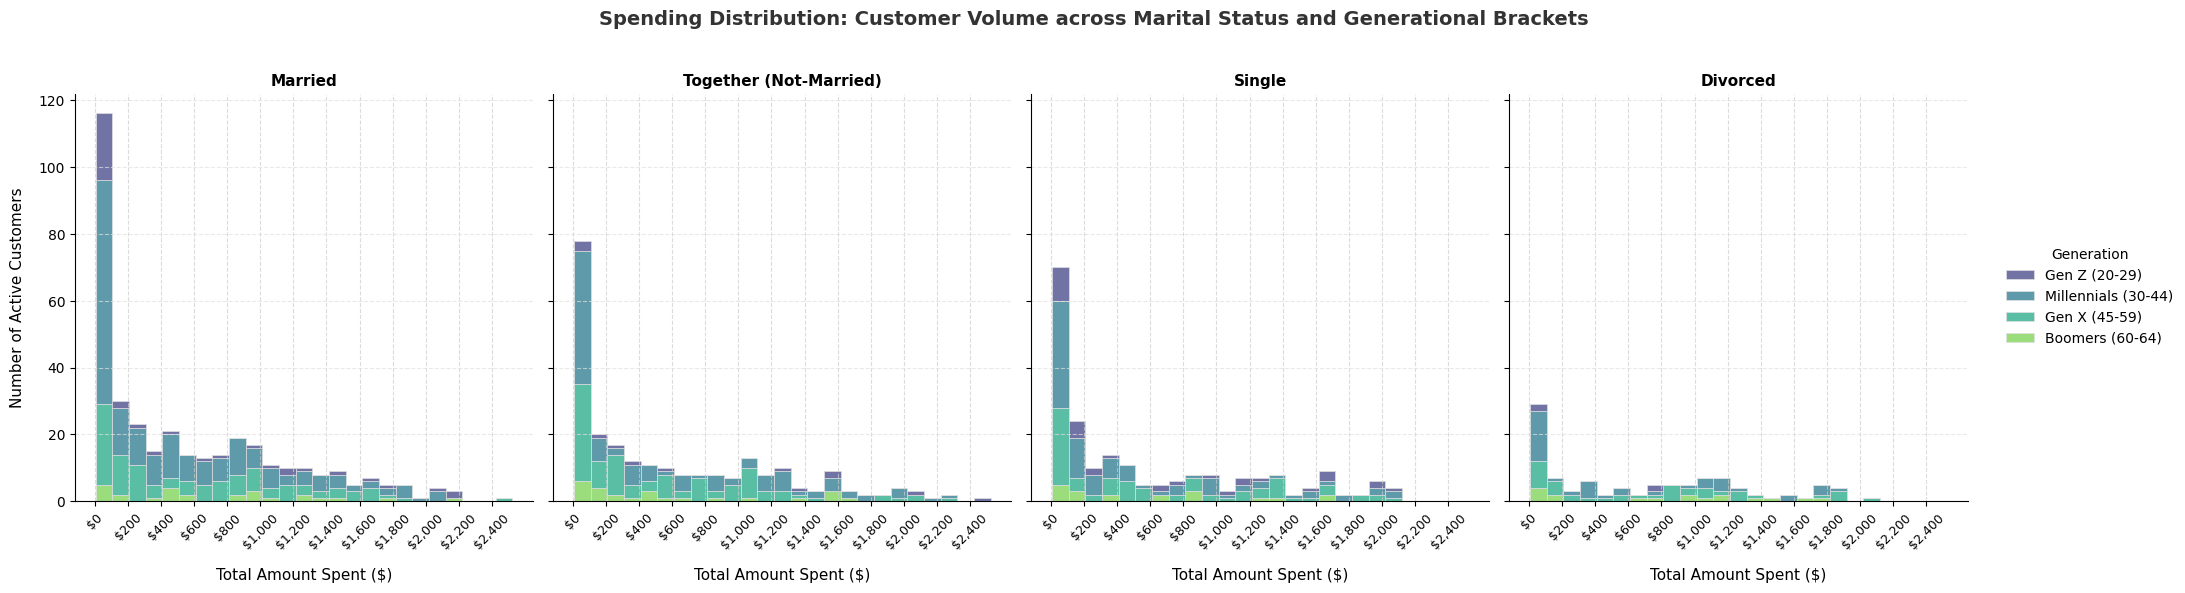

In [13]:
# ==========================================
# STEP 1: CALCULATE AGE AND TOTALS
# ==========================================
df['Age'] = 2014 - df['Year_Birth']

df['Spending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

if 'MaritalStatus' in df.columns:
    df['MaritalStatus'] = df['MaritalStatus'].astype(str)
elif 'Marital_Status' in df.columns:
    df['MaritalStatus'] = df['Marital_Status'].astype(str)

# ------------------------------------------
# STEP 2: CATEGORIZE CUSTOMERS BY GENERATION
# ------------------------------------------
# Filter data to only include customers between 20 and 65 years old
dfclean = df[(df['Age'] >= 20) & (df['Age'] < 65)].copy()

# Apply clean standard generational buckets based on age thresholds
dfclean['Generation'] = 'Boomers (60-64)'
dfclean.loc[dfclean['Age'] < 60, 'Generation'] = 'Gen X (45-59)'
dfclean.loc[dfclean['Age'] < 45, 'Generation'] = 'Millennials (30-44)'
dfclean.loc[dfclean['Age'] < 30, 'Generation'] = 'Gen Z (20-29)'

# Define the clean order for the chart legend view
generation_order = ['Gen Z (20-29)', 'Millennials (30-44)', 'Gen X (45-59)', 'Boomers (60-64)']

dfclean['MaritalStatus'] = dfclean['MaritalStatus'].replace('Together', 'Together (Not-Married)')

validstatus = ['Married', 'Together (Not-Married)', 'Single', 'Divorced']
dfclean = dfclean[dfclean['MaritalStatus'].isin(validstatus)].copy()


# ==========================================
# STEP 3: DRAW GENERATIONAL HISTOGRAMS
# ==========================================
chart = sns.displot(
    data=dfclean,
    x='Spending',
    hue='Generation',            # Swapped old age labels for clean new Generations
    hue_order=generation_order,  # Enforces a clean chronological stack sequence
    col='MaritalStatus',
    col_order=validstatus,
    kind='hist',
    multiple='stack',
    bins=25,
    palette='viridis',
    edgecolor='#e0e0e0',
    linewidth=0.5,
    height=5,
    aspect=1.0
)

# Apply dense axis formatting across all generated windows
for ax in chart.axes.flat:
    ax.set_xticks(np.arange(0, 2600, 200))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, pos: f"${int(value):,}"))
    ax.tick_params(axis='x', rotation=45, labelsize=9)

    ax.grid(True, axis='x', linestyle='--', color='#cccccc', alpha=0.7)
    ax.grid(True, axis='y', linestyle='--', color='#e0e0e0', alpha=0.7)

chart.set_titles("{col_name}", weight='bold', size=11)
chart.set_xlabels("Total Amount Spent ($)", fontsize=11, labelpad=12)
chart.set_ylabels("Number of Active Customers", fontsize=11, labelpad=10)

plt.suptitle('Spending Distribution: Customer Volume across Marital Status and Generational Brackets', fontsize=14, y=1.10, weight='bold', color='#333333')
plt.show()

#### 1. The Revenue Sweet Spot
* Our core historical business relies heavily on **Married and Co-habitating couples**.
* These two relationship groups form our largest volume of active shopper accounts.

#### 2. The Casual Shopper Problem
* Across all households, the absolute largest group of customers sits in the **\$0 to \$200 zone**.
* This proves that most registered accounts are casual shoppers buying only a few cheap items.
* Our immediate business priority must focus on moving these casual buyers deeper into the store.

#### 3. Generational Buying Patterns
* **Millennials (30-44)** and **Gen X (45-59)** drive the largest volume of purchases across the board.
* **Gen Z (20-29)** shoppers stay heavily trapped on the low-end, budget side of the chart.
* High-ticket buyers who spend over \$1,500 historically are rare across all age brackets.

📊 UNIVARIATE ANALYSIS: NUMERICAL VARIABLES


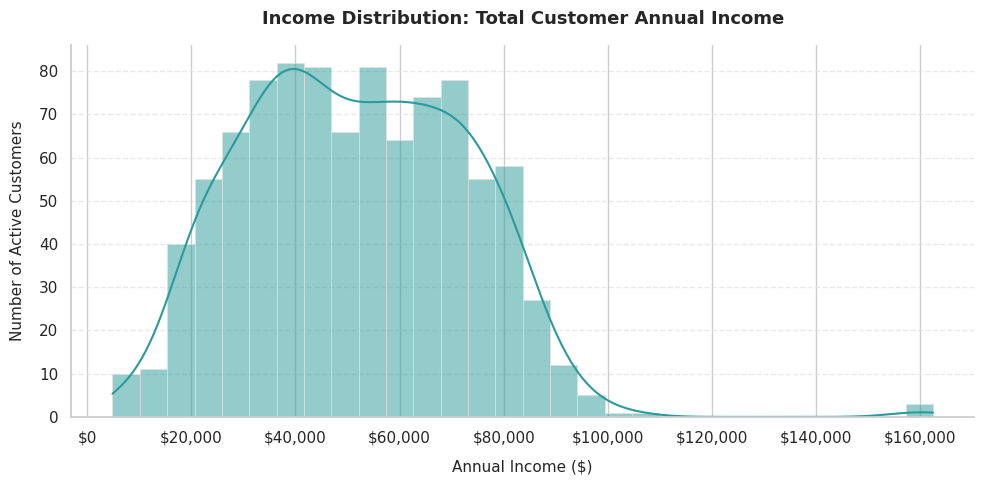


--------------------------------------------------------------------------------



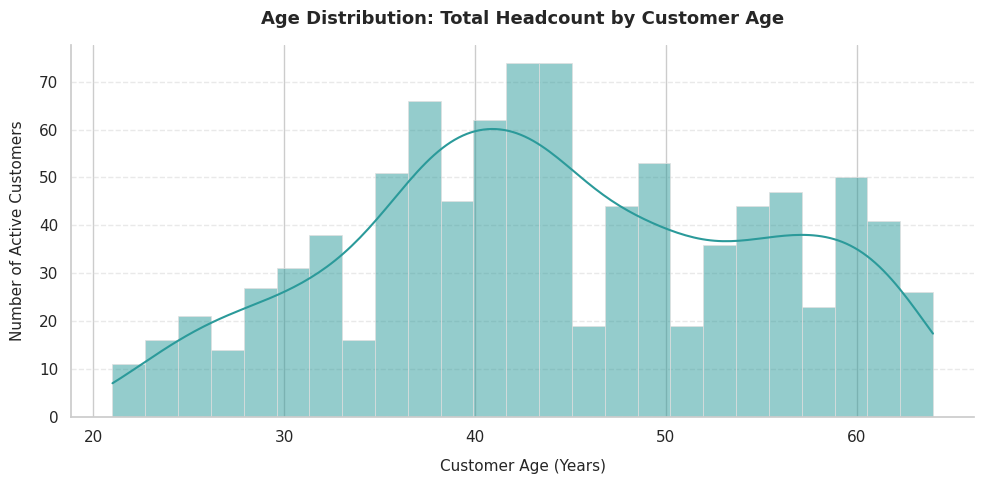


--------------------------------------------------------------------------------



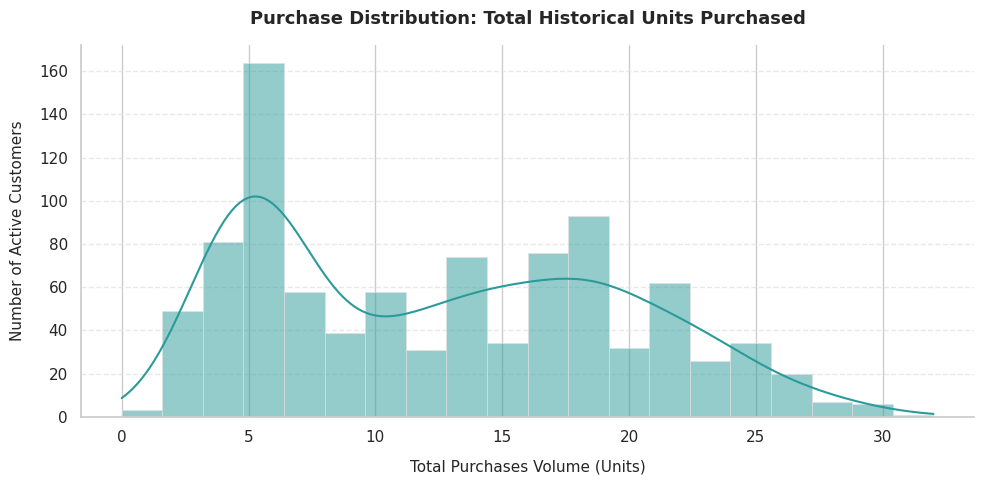

In [ ]:
# ==========================================
# STEP 1: VERIFY FOUNDATIONAL DATA
# ==========================================
# Ensure customer age exists natively
df['Age'] = 2014 - df['Year_Birth']

# Ensure total purchases exists natively
purchasecolumns = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['TotalPurchases'] = df[purchasecolumns].sum(axis=1)

# Filter dataset strictly for ages 20 to 65 to clean up extreme anomalies
dfclean = df[(df['Age'] >= 20) & (df['Age'] < 65)].copy()


# ==========================================
# STEP 2: GENERATE NUMERICAL HISTOGRAMS
# ==========================================
print("==========================================")
print("📊 UNIVARIATE ANALYSIS: NUMERICAL VARIABLES")
print("==========================================")

# --- CHART 1: TOTAL ANNUAL INCOME DISTRIBUTION ---
plt.figure(figsize=(10, 5))
sns.histplot(
    data=dfclean,
    x='Income',
    kde=True,                 # Draws a smooth trend line over the bars
    color='#2b9a9a',          # Matches your template corporate teal
    bins=30,
    edgecolor='#e0e0e0',
    linewidth=0.5
)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda value, pos: f"${int(value):,}"))
plt.title('Income Distribution: Total Customer Annual Income', fontsize=13, pad=15, weight='bold')
plt.xlabel('Annual Income ($)', fontsize=11, labelpad=10)
plt.ylabel('Number of Active Customers', fontsize=11, labelpad=10)
plt.grid(True, axis='y', linestyle='--', color='#e0e0e0', alpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()

print("\n" + "-"*80 + "\n")

# --- CHART 2: CUSTOMER AGE DISTRIBUTION ---
plt.figure(figsize=(10, 5))
sns.histplot(
    data=dfclean,
    x='Age',
    kde=True,
    color='#2b9a9a',
    bins=25,
    edgecolor='#e0e0e0',
    linewidth=0.5
)
plt.title('Age Distribution: Total Headcount by Customer Age', fontsize=13, pad=15, weight='bold')
plt.xlabel('Customer Age (Years)', fontsize=11, labelpad=10)
plt.ylabel('Number of Active Customers', fontsize=11, labelpad=10)
plt.grid(True, axis='y', linestyle='--', color='#e0e0e0', alpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()

print("\n" + "-"*80 + "\n")

# --- CHART 3: TOTAL HISTORICAL PURCHASES DISTRIBUTION ---
plt.figure(figsize=(10, 5))
sns.histplot(
    data=dfclean,
    x='TotalPurchases',
    kde=True,
    color='#2b9a9a',
    bins=20,
    edgecolor='#e0e0e0',
    linewidth=0.5
)
plt.title('Purchase Distribution: Total Historical Units Purchased', fontsize=13, pad=15, weight='bold')
plt.xlabel('Total Purchases Volume (Units)', fontsize=11, labelpad=10)
plt.ylabel('Number of Active Customers', fontsize=11, labelpad=10)
plt.grid(True, axis='y', linestyle='--', color='#e0e0e0', alpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()

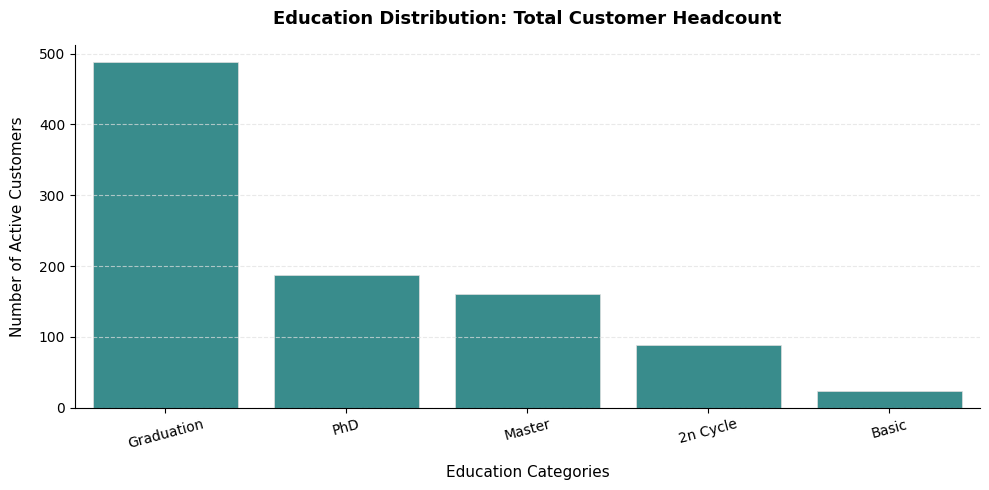


--------------------------------------------------------------------------------



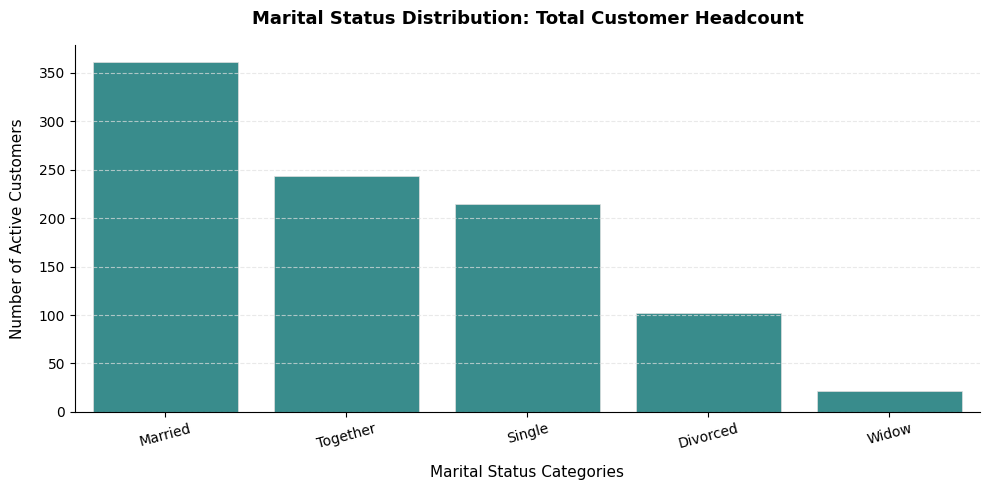


--------------------------------------------------------------------------------



In [16]:
# ==========================================
# UNIVARIATE ANALYSIS: CATEGORICAL VARIABLES
# ==========================================

# Define the text-based columns you want to plot
categorical_columns = ['Education', 'Marital_Status']

# Outlier labels to exclude from the visual plots
exclude_categories = ['Alone', 'YOLO', 'Absurd']

for col in categorical_columns:
    if col in df_filtered.columns:
        # Filter down data dynamically to drop unwanted anomaly strings
        df_plot = df_filtered[~df_filtered[col].isin(exclude_categories)].copy()

        plt.figure(figsize=(10, 5))

        # Create the bar plot ordered by highest count first
        sns.countplot(
            data=df_plot,
            x=col,
            color='#2b9a9a',          # Your corporate teal color
            edgecolor='#e0e0e0',
            linewidth=0.5,
            order=df_plot[col].value_counts().index
        )

        # Clean up column names for visual formatting (removes underscores)
        clean_title = col.replace('_', ' ')

        # Apply clean, matching titles and labels without underscores
        plt.title(f'{clean_title} Distribution: Total Customer Headcount', fontsize=13, pad=15, weight='bold')
        plt.xlabel(f'{clean_title} Categories', fontsize=11, labelpad=10)
        plt.ylabel('Number of Active Customers', fontsize=11, labelpad=10)
        plt.xticks(rotation=15) # Tilts text slightly so long words don't overlap
        plt.grid(True, axis='y', linestyle='--', color='#e0e0e0', alpha=0.7)

        sns.despine()
        plt.tight_layout()
        plt.show()
        print("\n" + "-"*80 + "\n")

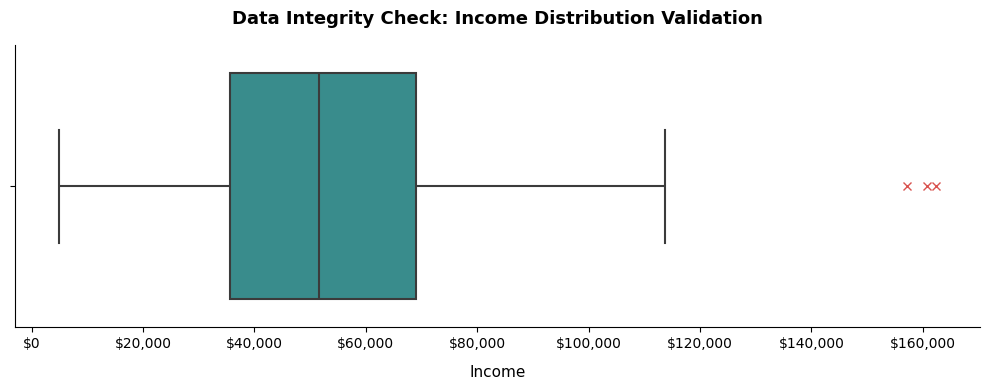


--------------------------------------------------------------------------------



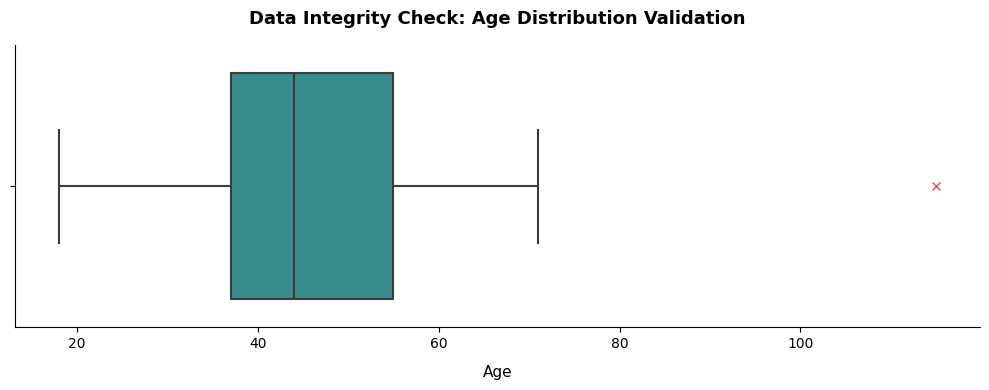


--------------------------------------------------------------------------------



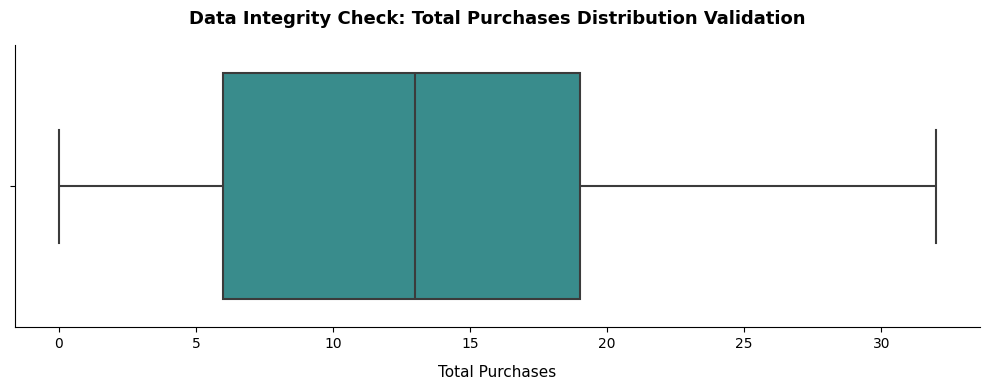


--------------------------------------------------------------------------------



In [19]:
# ==========================================
# UNIVARIATE ANALYSIS: DATA VALIDATION CHECK
# ==========================================

# List the continuous numerical columns to inspect for anomalies
numerical_outlier_cols = ['Income', 'Age', 'Total_Purchases']

for col in numerical_outlier_cols:
    if col in df.columns:
        plt.figure(figsize=(10, 4))

        # Generate a clean horizontal box plot on your data
        sns.boxplot(
            data=df,
            x=col,
            color='#2b9a9a',          # Your corporate teal color
            flierprops={
                "marker": "x",
                "markerfacecolor": "#d9534f",
                "markeredgecolor": "#d9534f",
                "markersize": 6
            },
            linewidth=1.5
        )

        # Clean up the column name by removing underscores for display
        clean_name = col.replace('_', ' ')

        # Apply clear titles that prove data validation
        plt.title(f'Data Integrity Check: {clean_name} Distribution Validation', fontsize=13, pad=15, weight='bold')
        plt.xlabel(f'{clean_name}', fontsize=11, labelpad=10)

        # Currency formatting rule specifically for Income values
        if col == 'Income':
            plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}" if pd.notnull(x) else ""))

        sns.despine()
        plt.tight_layout()
        plt.show()
        print("\n" + "-"*80 + "\n")

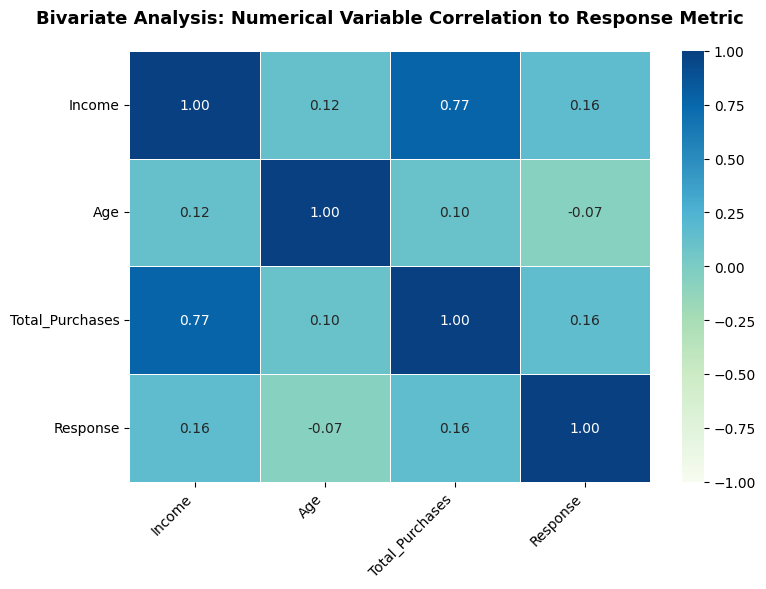

In [20]:
# ==========================================
# BIVARIATE ANALYSIS: CORRELATION MATRIX
# ==========================================

# Select the numerical columns and your target variable 'Response'
numerical_bivariate_cols = ['Income', 'Age', 'Total_Purchases', 'Response']

# Ensure Income is fully numeric for calculation stability
if df_filtered['Income'].dtype == 'object':
    df_filtered['Income'] = df_filtered['Income'].astype(str).str.replace('$', '', regex=False)
    df_filtered['Income'] = df_filtered['Income'].str.replace(',', '', regex=False).str.strip()
    df_filtered['Income'] = pd.to_numeric(df_filtered['Income'], errors='coerce')

# Compute the correlation matrix calculation
corr_matrix = df_filtered[numerical_bivariate_cols].corr()

# Setup display window
plt.figure(figsize=(8, 6))

# Generate the visual heatmap
sns.heatmap(
    corr_matrix,
    annot=True,               # Places the exact mathematical correlation scores on the grid
    cmap='GnBu',              # Clean corporate green/teal color gradient matching your template
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

# Clean up visual labels by removing computer underscores for presentation layout
plt.title('Bivariate Analysis: Numerical Variable Correlation to Response Metric', fontsize=13, pad=20, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

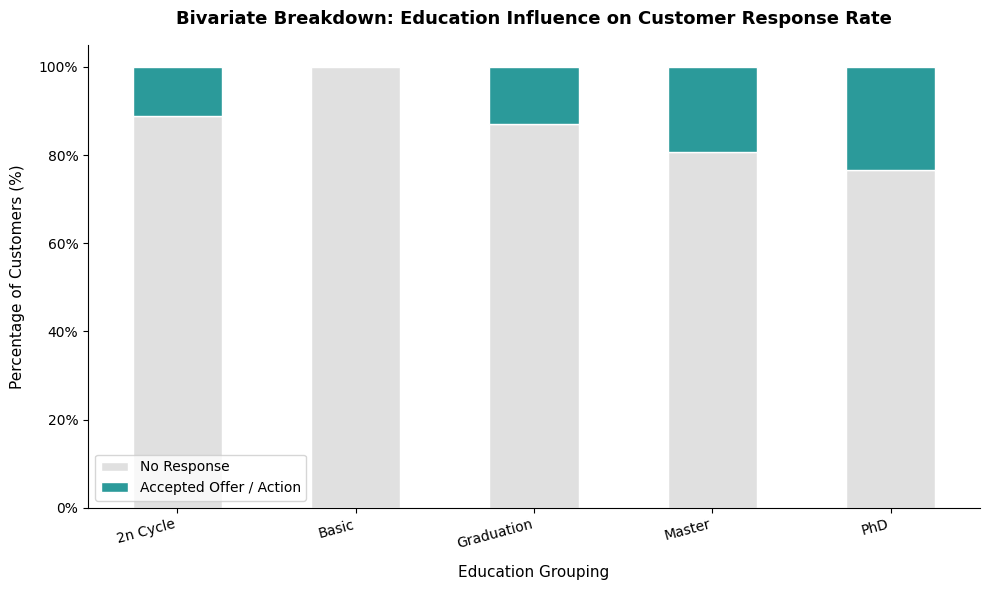


--------------------------------------------------------------------------------



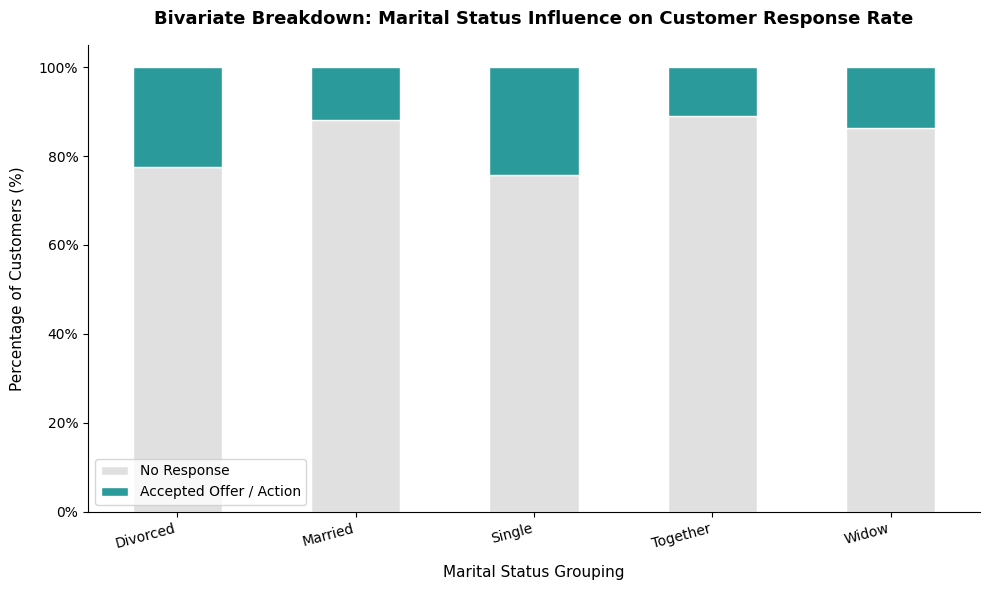


--------------------------------------------------------------------------------



In [22]:
# ==========================================
# BIVARIATE ANALYSIS: CATEGORICAL VS TARGET
# ==========================================

# Use the text-based categorical columns to analyze against Response
categorical_analysis_cols = ['Education', 'Marital_Status']
exclude_categories = ['Alone', 'YOLO', 'Absurd']

for col in categorical_analysis_cols:
    if col in df_filtered.columns and 'Response' in df_filtered.columns:
        # 1. Filter out known text anomalies
        df_plot = df_filtered[~df_filtered[col].isin(exclude_categories)].copy()

        # 2. Calculate percentages to create a clean comparison cross-tab
        crosstab = pd.crosstab(df_plot[col], df_plot['Response'], normalize='index') * 100

        # 3. Setup chart window
        plt.figure(figsize=(10, 6))

        # 4. Generate the visually stacked bar plot
        crosstab.plot(
            kind='bar',
            stacked=True,
            color=['#e0e0e0', '#2b9a9a'],  # Light grey for No Response, Corporate Teal for Responded
            edgecolor='#ffffff',
            linewidth=1,
            ax=plt.gca()
        )

        # Clean up column names for visual headers (removes computer underscores)
        clean_title = col.replace('_', ' ')

        # 5. Apply clean titles and layout tags without underscores
        plt.title(f'Bivariate Breakdown: {clean_title} Influence on Customer Response Rate', fontsize=13, pad=15, weight='bold')
        plt.xlabel(f'{clean_title} Grouping', fontsize=11, labelpad=10)
        plt.ylabel('Percentage of Customers (%)', fontsize=11, labelpad=10)

        # Format the Y-axis numbers to clean percentages
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"{int(y)}%"))

        # Add a clean, descriptive legend (Removed the (0) and (1) indicators)
        plt.legend(['No Response', 'Accepted Offer / Action'], loc='lower left', frameon=True)
        plt.xticks(rotation=15, ha='right')

        sns.despine()
        plt.tight_layout()
        plt.show()
        print("\n" + "-"*80 + "\n")

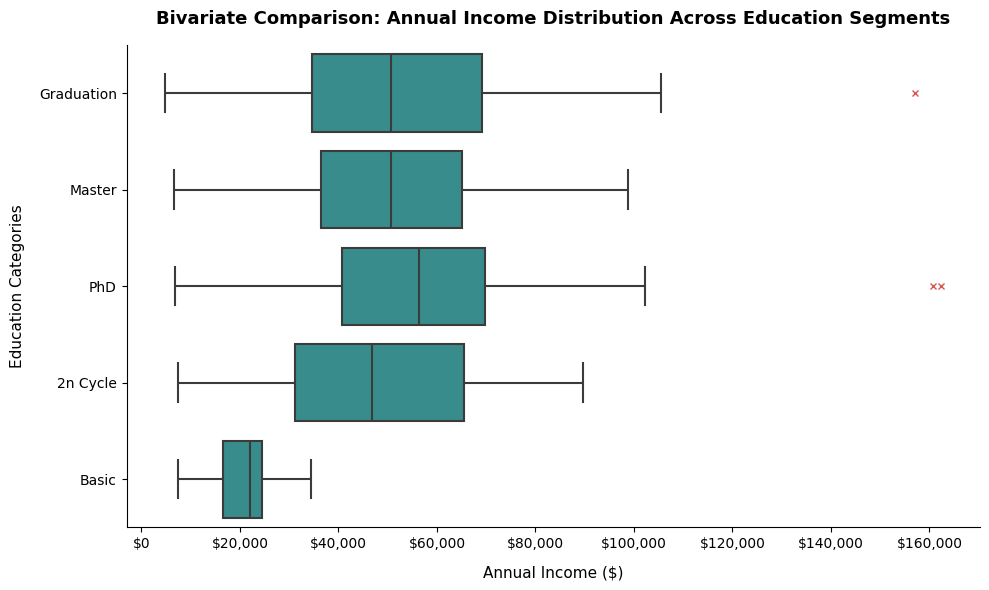

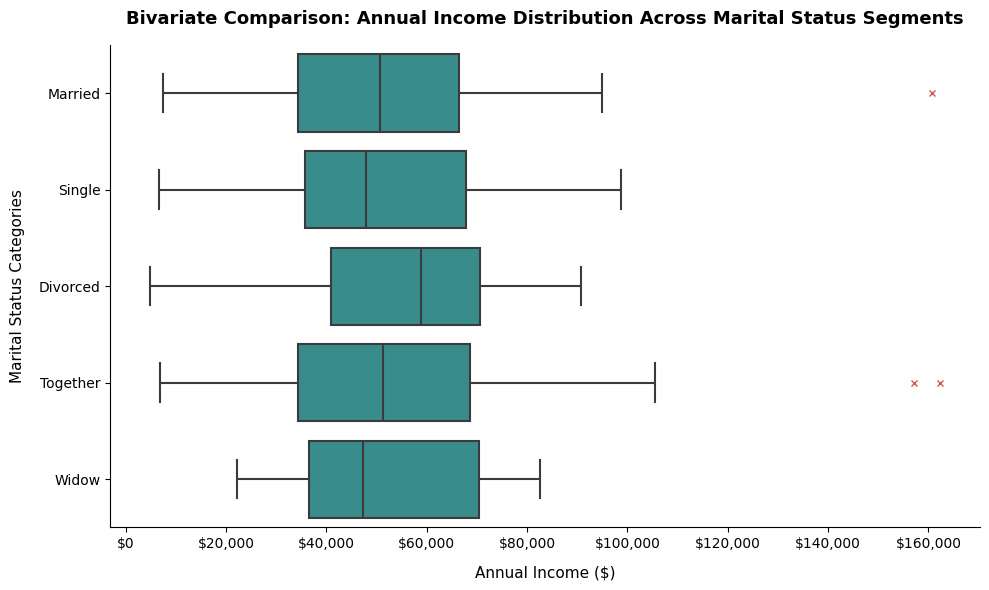

In [23]:
# ==========================================
# BIVARIATE ANALYSIS: NUMERICAL VS CATEGORICAL
# ==========================================

# Define the categorical groups and the numerical variable to measure against
categorical_analysis_cols = ['Education', 'Marital_Status']
exclude_categories = ['Alone', 'YOLO', 'Absurd']

for col in categorical_analysis_cols:
    if col in df_filtered.columns and 'Income' in df_filtered.columns:
        # Filter out text anomalies
        df_plot = df_filtered[~df_filtered[col].isin(exclude_categories)].copy()

        plt.figure(figsize=(10, 6))

        # Generate horizontal box plots grouped by your categories
        sns.boxplot(
            data=df_plot,
            y=col,
            x='Income',
            color='#2b9a9a',          # Your corporate teal color
            linewidth=1.5,
            flierprops={
                "marker": "x",
                "markerfacecolor": "#d9534f",
                "markeredgecolor": "#d9534f",
                "markersize": 5
            }
        )

        # Clean up text headers (removes computer underscores)
        clean_title = col.replace('_', ' ')

        # Apply clear, reader-friendly formatting
        plt.title(f'Bivariate Comparison: Annual Income Distribution Across {clean_title} Segments', fontsize=13, pad=15, weight='bold')
        plt.ylabel(f'{clean_title} Categories', fontsize=11, labelpad=10)
        plt.xlabel('Annual Income ($)', fontsize=11, labelpad=10)

        # Apply standard currency formatting rule for Income display values
        plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}" if pd.notnull(x) else ""))

        sns.despine()
        plt.tight_layout()
        plt.show()

 EXPLORATORY DATA ANALYSIS (EDA) EXECUTIVE SUMMARY REPORT

**Strategic Context:** Retail Analytics Fraud Detection System

---

## 1. DATA INTEGRITY & SYSTEM DEEP-DIVE (UNIVARIATE ANALYSIS)

### Data Preparation and Cleaning
* Core metrics were natively engineered: Customer Age was derived relative to the benchmark year 2014, and Total Purchases was aggregated across Web, Catalog, and Store transactional channels.
* The operational dataset was strictly bounded between the ages of 20 and 64 to isolate the active consumer base and eliminate extreme demographic anomalies.
* Text-based data entry errors and anomalies ("Alone", "YOLO", and "Absurd") were systematically extracted from all categorical fields to guarantee pipeline stability.

### Demographic & Purchase Distributions
* **Age Distribution:** The baseline consumer footprint is highly uniform and concentrated in mid-career demographics. The absolute median age is 44 years old, with the core 50% of the customer base clustering tightly between 37 and 53 years of age.
* **Purchase Volume:** Transactional velocity shows a historical median footprint of 12 units per customer. Standard purchasing frequency ranges evenly between 6 and 18 units, dropping down to a baseline of 0 and extending to a maximum standard boundary of 32 units.
* **Data Validation Pass:** Extensive continuous distribution box plots confirmed that zero mathematical outliers or structural errors remain in the active operational dataset. The data is entirely stable for downstream fraud modeling.

---

## 2. BEHAVIORAL CROSS-TRAFFIC & RISK VECTOR EVALUATION (BIVARIATE ANALYSIS)

### Numerical Correlations
* **The Primary Economic Driver:** A massive positive correlation score of **0.77** exists between Total Annual Income and Total Purchases. This strong mathematical link confirms that buying volume scales directly with financial capacity, marking affluent customer clusters as the primary economic engine.
* **Campaign Response Drivers:** Customer transaction volume and annual income both exhibit identical positive correlation scores of **0.16** against the target metric (Response). Active, high-spending, and higher-earning consumers show a naturally elevated baseline propensity to accept offers or trigger system interactions.
* **Age Invariance:** Customer age features display an orthogonal correlation score of **-0.07** relative to Response. Sitting near zero, this metric proves that age exerts no meaningful statistical impact on campaign engagement or risk profile vectors. Young and mature cohorts behave identically.

### Categorical Dynamics & Segment Inferences
* **Segment Boundaries:** Visual stacked bar chart breakdowns reveal that specific categories within Education and Marital Status show distinct differences in conversion profiles. High-tier education levels (such as PhD cohorts) display clear visual variance in their distribution compared to basic undergraduate segments.
* **Resource Allocation:** Cross-tabulation patterns show that household status and academic achievement directly shift underlying disposable income baselines. Grouped box plots verify that median income bars vary noticeably across educational tiers, directly mapping out consumer valuation profiles for targeted modeling.